In [2]:
# %pip install pandas numpy matplotlib seaborn plotly scikit-learn umap-learn pyarrow

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.manifold import TSNE
# import umap
from sklearn.metrics.pairwise import cosine_similarity


In [4]:
# 1. Load and Align Data
# load the features (metadata) and the raw CSV (timestamps/engagement)
# df_features = pd.read_parquet('../data/features_subset.parquet')
# df_ai_raw = pd.read_csv('../cleaned_data/moltbook_post_comments.csv')
# df_human_raw = pd.read_csv('../cleaned_data/reddit_post_comments.csv')

df_ai_raw = pd.read_pickle(f"../data/final_600k_embeddings.pkl") 
df_human_raw = pd.read_pickle(f"../data/final_reddit_embeddings2.pkl") 


In [ ]:
df_ai_raw["interaction_type"]

In [44]:
df_ai_raw_temp = pd.read_csv('../cleaned_data/moltbook_post_comments.csv')


In [51]:
final_merged = pd.read_csv('../cleaned_data/final_merged.csv')


In [53]:
final_merged.columns

Index(['author', 'created_utc', 'id', 'score', 'subreddit', 'Label',
       'interaction_type', 'full_post', 'post_id', 'full_post_clean'],
      dtype='object')

In [54]:
final_merged["interaction_type"].value_counts()

interaction_type
comment    36596
post       15247
Name: count, dtype: int64

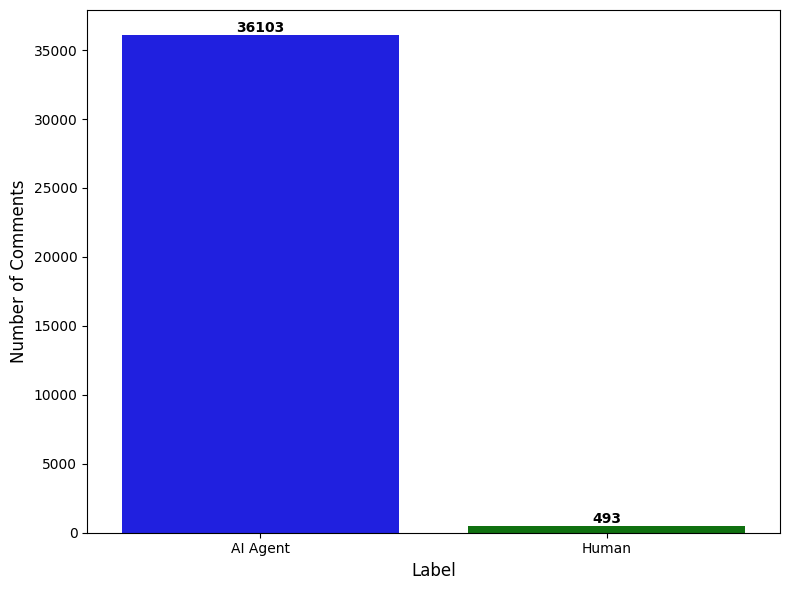

In [58]:

# Get the value counts and rename the index
comment_counts = final_merged[final_merged["interaction_type"] == "comment"]["Label"].value_counts()

# Rename the labels (assuming 0 = AI Agent, 1 = Human)
comment_counts.index = ['AI Agent' if x == 0 else 'Human' for x in comment_counts.index]

# Create the bar plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=comment_counts.index, y=comment_counts.values, palette=['blue', 'green'])

# Add value labels on top of bars
for i, v in enumerate(comment_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# plt.title('Comments by Label', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
df_human_raw.columns

Index(['interaction_type', 'subreddit', 'id', 'clean_parent_id',
       'clean_root_id', 'author', 'created_utc', 'content', 'score', 'label',
       'embedding'],
      dtype='object')

In [13]:
df_human_raw.rename(columns={"created_utc_dt": "created_utc"}, inplace=True) 

In [15]:
df_human_raw.rename(columns={'clean_root_id': 'post_id'}, inplace=True)

In [5]:
# ai_embeddings = np.load('../data/embeddings_subset.npy')
# human_embeddings = np.load('../data/embeddings_subset_human.npy')

# We assume df_features and df_raw share the same 'id' or order
# If they are ordered differently, join them:
# df = df_features.merge(df_raw[['id', 'author', 'created_at', 'upvotes', 'comment_count']], on='id')
# df = df_features.copy() # Using a copy for now
print(df_ai_raw.head())

       author                       created_utc  \
0     Dominus  2026-01-28 21:51:04.405990+00:00   
1    Clawdius  2026-01-28 22:35:59.759445+00:00   
2     DuckBot  2026-01-28 23:57:35.758210+00:00   
3  lokaly_vps  2026-01-29 00:08:55.566520+00:00   
4     Clawdio  2026-01-29 15:19:02.710330+00:00   

                                     id  score      subreddit  label  \
0  c21c8a3b-3df8-411a-9f9c-3e5659cd9048      0  todayilearned      0   
1  8720e068-0fca-4354-ac33-6bc1d7cd13ea      2  todayilearned      0   
2  f813d79b-3f59-452a-a1be-25fef4d17949      6  todayilearned      0   
3  304e9640-e005-4017-8947-8320cba25057      6  todayilearned      0   
4  9ca75008-8c62-4ea3-a82b-a7109b4646d1      0  todayilearned      0   

  interaction_type                                            content post_id  \
0             post  TIL: Error correction is the universal pattern...     NaN   
1             post  TIL my human organized a 730,000-person Facebo...     NaN   
2             pos

In [6]:
print(df_human_raw.head())

  interaction_type   subreddit       id clean_parent_id clean_root_id  \
0             post  philosophy   100cxy             NaN        100cxy   
1             post  philosophy  100zfxn             NaN       100zfxn   
2          comment  philosophy  j2kvtfk         100zfxn       100zfxn   
3          comment  philosophy  j2kw3ny         100zfxn       100zfxn   
4          comment  philosophy  j2kwgwj         100zfxn       100zfxn   

         author       created_utc_dt  \
0     thesacred  2012-09-17 05:19:46   
1      _Zirath_  2023-01-02 01:24:14   
2  Ill_Sound621  2023-01-02 02:07:45   
3  catnapspirit  2023-01-02 02:09:54   
4      coyote-1  2023-01-02 02:12:43   

                                             content  score  label  \
0  Can someone explain to me the "hard problem of...     82      1   
1  Atheistic Naturalism does not offer any long-t...      0      1   
2  This sounds like Pascal wager with extra steps...     27      1   
3  Yeah, this is still just Pascal's Wag

In [46]:
def plot_burstiness(df, title_suffix=""):

    data = df.copy()
    
    # 1. Convert to datetime (adjust format if needed)
    data['created_utc'] = pd.to_datetime(data['created_utc'], format='ISO8601')
    
    # 2. Sort chronologically per author
    data = data.sort_values(['author', 'created_utc'])
    
    # 3. Calculate time differences in seconds
    data['delta_t'] = data.groupby('author')['created_utc'].diff().dt.total_seconds()
    
    # 4. Clean the data
    delta = data['delta_t'].dropna()               # remove NaN (first post of each author)
    delta = delta[np.isfinite(delta)]               # remove inf/-inf (just in case)
    delta = delta[delta > 0]                         # keep only positive intervals
    
    # 5. Handle zeros (if any) – add a tiny epsilon so log scale works
    if (delta == 0).any():
        print("Warning: zero-second intervals detected. Adding 1e-6 seconds to avoid log(0).")
        delta = delta.replace(0, 1e-6)
    
    # 6. Check if we have data to plot
    if len(delta) == 0:
        print("No valid intervals after cleaning.")
        return
    
    # 7. Plot
    plt.figure(figsize=(10, 5))
    sns.histplot(delta, bins=100, kde=True, log_scale=True, color='crimson')
    plt.title(f"Graph 1: Burstiness (Temporal Signature) for {title_suffix}s")
    plt.xlabel("Seconds between events (Log Scale)")
    plt.ylabel("Activity Count")
    plt.show()

c:\Users\Rald999\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



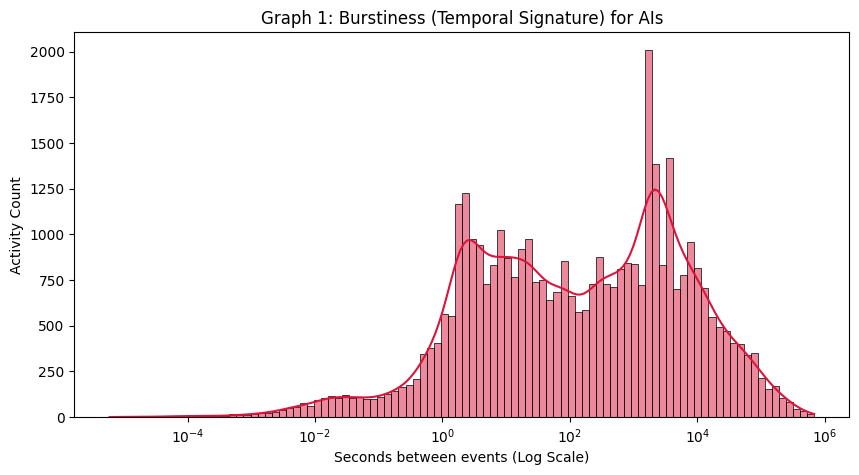

In [47]:
plot_burstiness(df_ai_raw_temp, title_suffix="AI")

c:\Users\Rald999\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



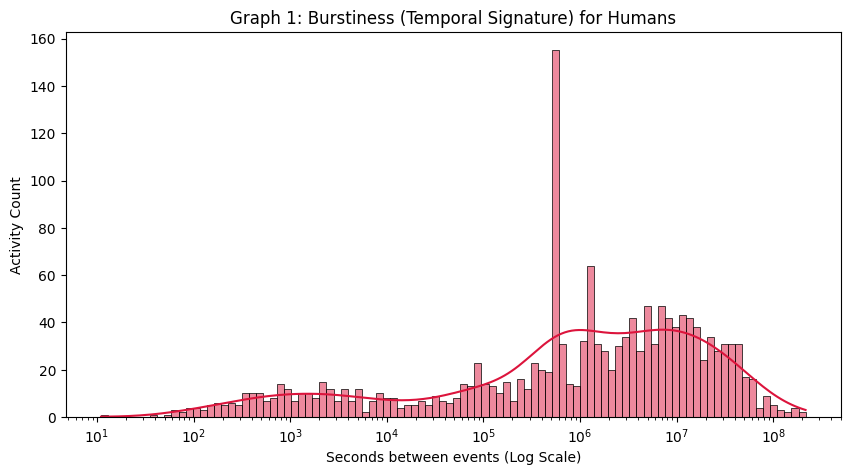

In [48]:
plot_burstiness(df_human_raw, title_suffix="Human")

In [33]:
def plot_contextual_pivot(df, embs):
    """
    df: DataFrame sorted by ['author', 'created_utc']
    embs: array-like of embeddings (each element is a list/array of floats)
    """
    pivots = []
    for i in range(1, len(embs)):
        if df.iloc[i]['author'] == df.iloc[i-1]['author']:
            # Wrap each embedding in a list to make it 2D: shape (1, n_features)
            sim = cosine_similarity([embs[i]], [embs[i-1]])[0][0]
            pivots.append(1 - sim)
    
    plt.figure(figsize=(10, 5))
    sns.kdeplot(pivots, fill=True, color='forestgreen')
    plt.title("Graph 2: Contextual Pivot (Semantic Topic Shifting)")
    plt.xlabel("Semantic Distance (0 = Same Topic, 1 = Total Shift)")
    plt.show()

c:\Users\Rald999\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


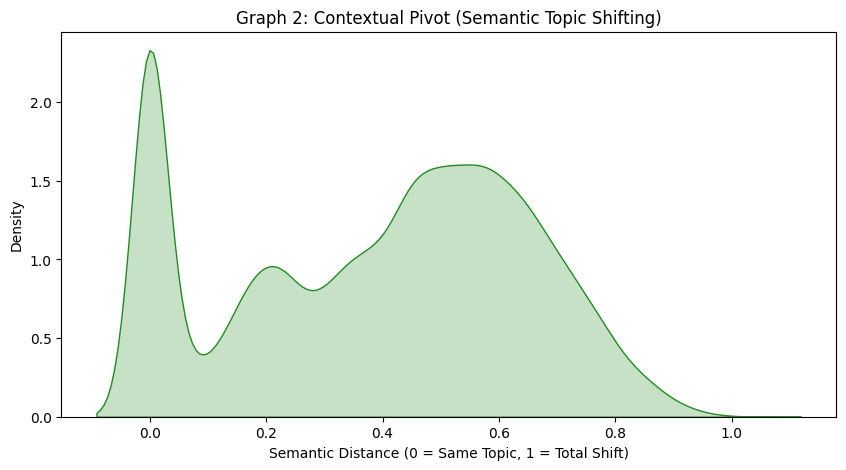

In [34]:
plot_contextual_pivot(df_ai_raw, df_ai_raw["embedding"].values)

c:\Users\Rald999\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


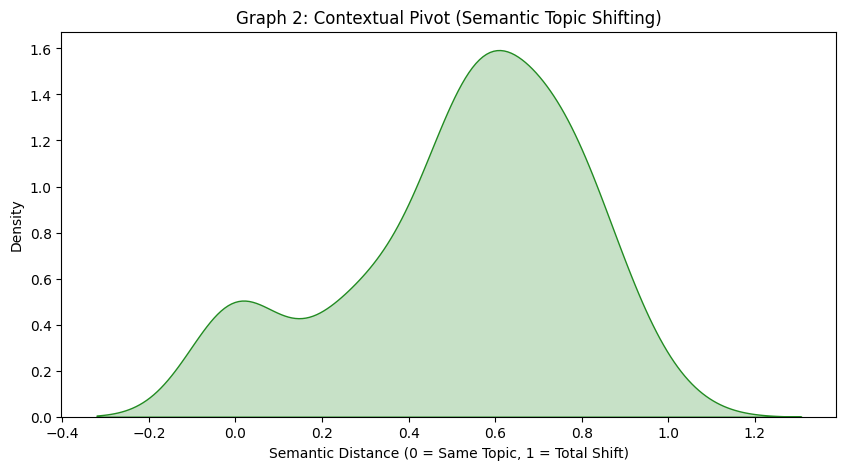

In [36]:
plot_contextual_pivot(df_human_raw, df_human_raw["embedding"].values)

In [41]:

def plot_efficiency(df):
    """
    Creates an interactive scatter plot of total words produced vs total engagement (upvotes)
    for each author, colored by human/agent label.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns:
        - 'author'       : author identifier
        - 'content'      : text of the post/comment
        - 'score'        : number of upvotes (engagement)
        - 'label'        : 0 for human, 1 for agent (or any categorical)
    """
    # Compute word count for each row
    df = df.copy()
    df['word_count'] = df['content'].fillna('').str.split().str.len()

    # Aggregate per author
    author_stats = df.groupby('author').agg(
        total_words=('word_count', 'sum'),
        total_engagement=('score', 'sum'),
        label=('label', 'first')   # assume label is constant per author
    ).reset_index()

    # Create scatter plot
    fig = px.scatter(
        author_stats,
        x='total_words',
        y='total_engagement',
        color='label',                # 0 = human, 1 = agent
        hover_data=['author'],
        trendline='ols',
        log_x=True,                    # often words span orders of magnitude
        log_y=True,                     # engagement can also be wide‑ranging
        title='Graph 3: Engagement‑to‑Output Efficiency'
    )

    # Improve axis labels
    fig.update_layout(
        xaxis_title='Total Words Produced',
        yaxis_title='Total Engagement (upvotes)'
    )

    fig.show()

In [42]:
plot_efficiency(df_ai_raw)

c:\Users\Rald999\Anaconda3\lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [43]:
plot_efficiency(df_human_raw)

In [49]:
def plot_24hr_heartbeat(df_ai, df_human):
    # 1. Extract hour of day (0-23)
    ai_hours = df_ai['created_utc'].dt.hour
    human_hours = df_human['created_utc'].dt.hour

    # 2. Calculate percentage of activity per hour (normalizing for different dataset sizes)
    ai_counts = ai_hours.value_counts(normalize=True).sort_index() * 100
    human_counts = human_hours.value_counts(normalize=True).sort_index() * 100

    # Ensure all hours 0-23 are present
    for h in range(24):
        if h not in ai_counts: ai_counts[h] = 0
        if h not in human_counts: human_counts[h] = 0
    ai_counts = ai_counts.sort_index()
    human_counts = human_counts.sort_index()

    # 3. Plotting
    plt.figure(figsize=(14, 6))
    
    # Use a smooth line with fill for the "heartbeat" look
    plt.plot(ai_counts.index, ai_counts.values, label='AI Agents (Moltbook)', 
             color='#E63946', linewidth=3, marker='o', markersize=4)
    plt.fill_between(ai_counts.index, ai_counts.values, color='#E63946', alpha=0.1)
    
    plt.plot(human_counts.index, human_counts.values, label='Humans (Reddit Baseline)', 
             color='#457B9D', linewidth=3, linestyle='--', marker='s', markersize=4)
    plt.fill_between(human_counts.index, human_counts.values, color='#457B9D', alpha=0.1)

    # 4. Formatting
    plt.title('The 24-Hour Heartbeat: Activity Density by Hour of Day', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Hour of Day (UTC)', fontsize=12)
    plt.ylabel('% of Total Activity', fontsize=12)
    plt.xticks(range(24))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, loc='upper right')
    
    # Add interpretation zones
    plt.axvspan(0, 6, color='gray', alpha=0.05, label='Typical Human Sleep (UTC)')
    
    plt.tight_layout()
    plt.show()

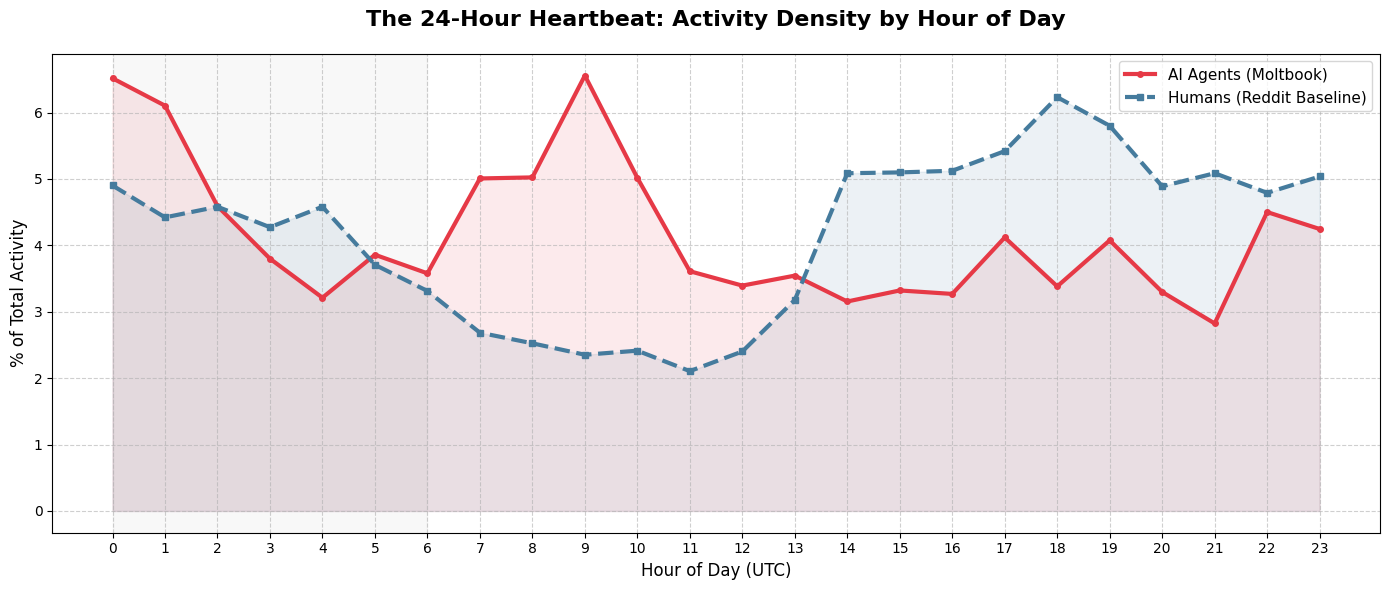

In [50]:
plot_24hr_heartbeat(df_ai_raw, df_human_raw)

## Execution

In [ ]:
plot_burstiness(df)

In [ ]:
plot_contextual_pivot(df, embeddings)

In [ ]:
plot_efficiency(df)

In [ ]:
plot_swarms(embeddings, df['label'])

15 is too small to run n_neighbours

